# Классическое машинное обучение
### Линейная алгебра в машинном обучении. Матричные разложения. Спектральное разложение матриц. SVD.

In [1]:
!pip install --upgrade --quiet pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 68.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.


In [2]:
import numpy as np
import scipy as sp

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.set_printoptions(suppress=True)

### Задача 1

Реализуйте наивный степенной метод поиска **доминирующего** собственного вектора $v_1$ для квадратной матрицы $A$.

Степенной метод работает следующим образом:
1. Генерируется случайный единичный вектор $v_0$
2. Шаг: $v_{i+1} := \dfrac{Av_i}{\|Av_i\|}$

Повторяем до сходимости: $\cos \angle (v_i, v_{i+1}) \rightarrow 1$.

Тест 1: Диагональная матрица
Матрица A:
 [[5 0 0]
 [0 3 0]
 [0 0 1]]
Итерация 0: cos(angle) = 0.8235846675

Результат:
Собственный вектор: [-0.99999999 -0.00013413  0.        ]
Собственное значение: 5.000000
Итераций: 14
Косинус угла в конце: 0.9999999960
Невязка ||Av - λv||: 2.68e-04

Тест 2: Симметричная матрица 3x3
Матрица A:
 [[4 1 1]
 [1 3 1]
 [1 1 2]]

Результат:
Собственный вектор: [-0.75572555 -0.520732   -0.3971361 ]
Собственное значение: 5.214320
Итераций: 14

Тест 3: Поиск 2 собственных векторов с дефляцией

Поиск 1-го собственного вектора...
Найден: λ = 5.214320, итераций: 12

Поиск 2-го собственного вектора...
Найден: λ = 2.460811, итераций: 13

Найденные пары:
1: λ = 5.214320, v = [-0.75574968 -0.52070379 -0.39712717]
2: λ = 2.460811, v = [-0.63185739  0.73923006  0.23301321]

Скалярное произведение векторов: 0.000070

Тест 4: Случайная матрица 5x5
Собственное значение: 13.294715
Итераций: 10


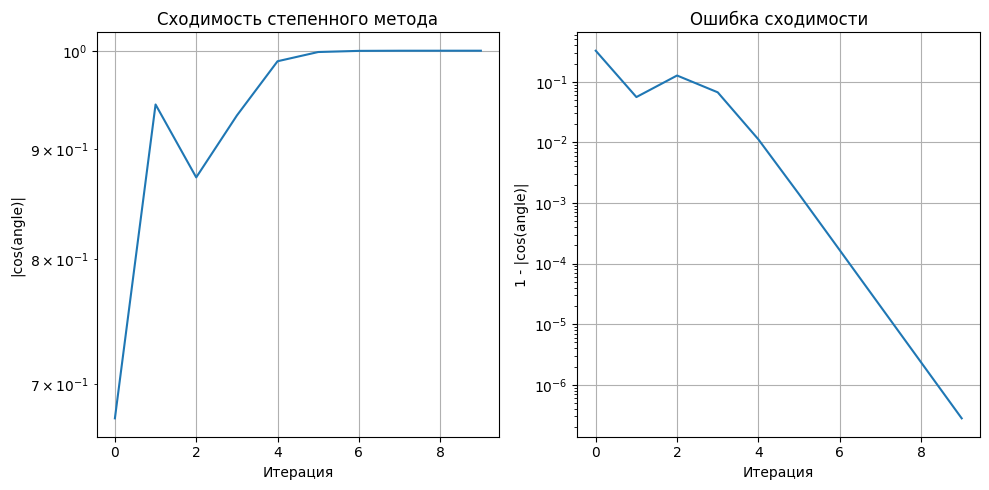

In [4]:
def power_iteration(A, max_iterations=1000, tolerance=1e-10, verbose=False):
    """
    Наивный степенной метод для поиска доминирующего собственного вектора.

    Параметры:
    A : numpy.ndarray
        Квадратная матрица
    max_iterations : int
        Максимальное количество итераций
    tolerance : float
        Критерий сходимости (близость косинуса угла к 1)
    verbose : bool
        Выводить информацию о процессе

    Возвращает:
    v : numpy.ndarray
        Доминирующий собственный вектор (нормированный)
    lambda_ : float
        Соответствующее собственное значение
    iterations : int
        Количество выполненных итераций
    convergence_history : list
        История значений косинуса угла
    """

    # Проверка, что матрица квадратная
    n = A.shape[0]
    assert A.shape[1] == n, "Матрица должна быть квадратной"

    # 1. Генерируем случайный единичный вектор
    v = np.random.randn(n)
    v = v / np.linalg.norm(v)

    convergence_history = []

    for i in range(max_iterations):
        # Сохраняем предыдущий вектор для вычисления косинуса
        v_prev = v.copy()

        # 2. Шаг степенного метода: v_{i+1} = A * v_i / ||A * v_i||
        v_new = A @ v
        norm = np.linalg.norm(v_new)

        # Проверка на нулевой вектор (возможно, A = 0)
        if norm < 1e-15:
            print("Внимание: норма близка к нулю, матрица, возможно, нулевая")
            return v, 0, i, convergence_history

        v_new = v_new / norm

        # Вычисляем косинус угла между v_i и v_{i+1}
        cos_angle = np.abs(np.dot(v_prev, v_new))  # Берем модуль для учета возможной смены знака
        convergence_history.append(cos_angle)

        if verbose and i % 100 == 0:
            print(f"Итерация {i}: cos(angle) = {cos_angle:.10f}")

        # Проверка сходимости
        if np.abs(1 - cos_angle) < tolerance:
            v = v_new
            break

        v = v_new

    # Вычисляем соответствующее собственное значение (отношение Рэлея)
    # λ = (v^T * A * v) / (v^T * v), но так как v нормирован, знаменатель = 1
    lambda_ = v @ (A @ v)

    return v, lambda_, i+1, convergence_history


def power_iteration_with_deflation(A, num_eigenvectors=1, **kwargs):
    """
    Степенной метод с процедурой исчерпывания (дефляции)
    для нахождения нескольких доминирующих собственных векторов.

    Параметры:
    A : numpy.ndarray
        Квадратная матрица
    num_eigenvectors : int
        Количество собственных векторов для поиска
    **kwargs
        Дополнительные параметры для power_iteration

    Возвращает:
    eigenvalues : list
        Список собственных значений
    eigenvectors : list
        Список собственных векторов
    """
    n = A.shape[0]
    eigenvalues = []
    eigenvectors = []

    # Копируем матрицу для дефляции
    A_deflated = A.copy()

    for k in range(num_eigenvectors):
        print(f"\nПоиск {k+1}-го собственного вектора...")

        # Находим доминирующую пару для текущей матрицы
        v, lambda_, iterations, history = power_iteration(
            A_deflated, **kwargs
        )

        eigenvalues.append(lambda_)
        eigenvectors.append(v)

        print(f"Найден: λ = {lambda_:.6f}, итераций: {iterations}")

        # Процедура дефляции Hotelling
        # A_new = A - λ * v * v^T
        A_deflated = A_deflated - lambda_ * np.outer(v, v)

    return eigenvalues, eigenvectors


def test_power_iteration():
    """Тестирование степенного метода"""

    # Тест 1: Диагональная матрица
    print("="*50)
    print("Тест 1: Диагональная матрица")
    print("="*50)

    A1 = np.diag([5, 3, 1])
    print("Матрица A:\n", A1)

    v, lambda_, iterations, history = power_iteration(A1, verbose=True, tolerance=1e-8)

    print(f"\nРезультат:")
    print(f"Собственный вектор: {v}")
    print(f"Собственное значение: {lambda_:.6f}")
    print(f"Итераций: {iterations}")
    print(f"Косинус угла в конце: {history[-1]:.10f}")

    # Проверка: A*v должно быть равно λ*v
    Av = A1 @ v
    lambda_v = lambda_ * v
    print(f"Невязка ||Av - λv||: {np.linalg.norm(Av - lambda_v):.2e}")

    # Тест 2: Симметричная матрица
    print("\n" + "="*50)
    print("Тест 2: Симметричная матрица 3x3")
    print("="*50)

    A2 = np.array([
        [4, 1, 1],
        [1, 3, 1],
        [1, 1, 2]
    ])
    print("Матрица A:\n", A2)

    v, lambda_, iterations, history = power_iteration(A2, tolerance=1e-8)

    print(f"\nРезультат:")
    print(f"Собственный вектор: {v}")
    print(f"Собственное значение: {lambda_:.6f}")
    print(f"Итераций: {iterations}")

    # Тест 3: Поиск нескольких собственных векторов с дефляцией
    print("\n" + "="*50)
    print("Тест 3: Поиск 2 собственных векторов с дефляцией")
    print("="*50)

    eigenvalues, eigenvectors = power_iteration_with_deflation(
        A2, num_eigenvectors=2, tolerance=1e-8
    )

    print("\nНайденные пары:")
    for i, (lambda_, v) in enumerate(zip(eigenvalues, eigenvectors)):
        print(f"{i+1}: λ = {lambda_:.6f}, v = {v}")

    # Проверка ортогональности (для симметричной матрицы)
    if len(eigenvectors) > 1:
        dot_product = np.dot(eigenvectors[0], eigenvectors[1])
        print(f"\nСкалярное произведение векторов: {dot_product:.6f}")

    # Тест 4: Случайная матрица 5x5
    print("\n" + "="*50)
    print("Тест 4: Случайная матрица 5x5")
    print("="*50)

    np.random.seed(42)  # Для воспроизводимости
    A3 = np.random.randn(5, 5)
    A3 = A3 @ A3.T  # Делаем симметричной для гарантии сходимости

    v, lambda_, iterations, history = power_iteration(A3, max_iterations=5000, tolerance=1e-6)

    print(f"Собственное значение: {lambda_:.6f}")
    print(f"Итераций: {iterations}")

    # Визуализация сходимости
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history)
    plt.xlabel('Итерация')
    plt.ylabel('|cos(angle)|')
    plt.title('Сходимость степенного метода')
    plt.grid(True)
    plt.yscale('log')

    plt.subplot(1, 2, 2)
    plt.plot(1 - np.array(history))
    plt.xlabel('Итерация')
    plt.ylabel('1 - |cos(angle)|')
    plt.title('Ошибка сходимости')
    plt.grid(True)
    plt.yscale('log')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    test_power_iteration()

In [5]:
def power_1(A: np.ndarray, thres=(1 - 1e-10), max_iters=1000, return_intermediate=False) -> np.array:
    """
    Power iteration to find dominant eigenvector of matrix A.

    Args:
        A: Square matrix
        thres: Convergence threshold (cosine similarity)
        max_iters: Maximum iterations
        return_intermediate: Return all intermediate vectors if True

    Returns:
        Dominant eigenvector or matrix of all iterates
    """
    n = A.shape[0]
    v = np.random.normal(size = n)
    v /= np.linalg.norm(v)
    interm = [v]
    for _ in range(max_iters):
      v_new = A.dot(v)
      v_new /= np.linalg.norm(v_new)
      interm.append(v_new)
      if np.abs(v @ v_new) > thres:
        break
      v = v_new
    else:
      raise Exception('Did not  converge')
    if return_intermediate:
      return np.stack(interm).T
    return v_new

In [6]:
# Do not change the tests!
# They are for your convenience.
for j in range(5):
    P = np.random.normal(size=(4, 4))
    P /= np.linalg.norm(P)
    d = np.random.standard_cauchy(size=(4,))
    A = np.einsum('mn,n,nk->mk', P, d, np.linalg.inv(P))
    eig = np.linalg.eig(A)
    v_true = eig.eigenvectors[:, np.abs(eig.eigenvalues).argmax()]
    v_true = v_true / np.linalg.norm(v_true)
    v_power = power_1(A, thres=0.99)
    v_power_norm = np.linalg.norm(v_power)

    np.testing.assert_almost_equal(
        actual=v_power_norm,
        desired=1.0,
        err_msg=f"Test {j + 1}: Incorrect vector norm: {v_power_norm}"
    )
    np.testing.assert_(
        val=np.abs(v_true @ v_power) > 0.95,
        msg=f"Test {j + 1}: Incorrect eigenvector (try restarting?)"
    )

#### Визуализация степенного метода

Если ваша функция работает правильно, то следующий код покажет то, насколько быстро метод сходится для матрицы 2x2 с собственными числами 10 и 7.

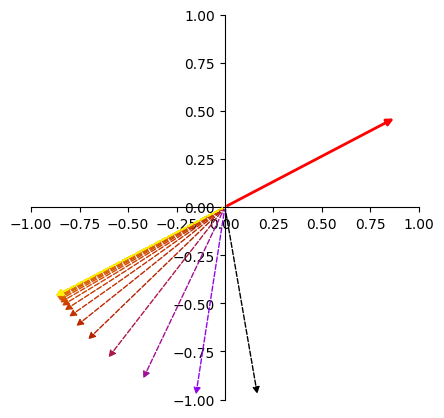

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

P = np.random.normal(size=(2, 2))
P /= np.linalg.norm(P)
d = np.array([10, 7])
A = np.einsum('mn,n,nk->mk', P, d, np.linalg.inv(P))
eig = np.linalg.eig(A)
v_true = eig.eigenvectors[:, np.abs(eig.eigenvalues).argmax()]
v_true = v_true / np.linalg.norm(v_true)
vs_power = power_1(A, max_iters=50, return_intermediate=True)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
palette = sns.color_palette('gnuplot', as_cmap=True)
for i, c_coef in enumerate(np.cbrt(np.linspace(0, 0.95, vs_power.shape[1]))):
    v_power = vs_power[:, i]
    ax.annotate('', xytext=tuple(v_power), xy=(0, 0),
                arrowprops=dict(arrowstyle="<|-", linestyle='--', color=palette(c_coef)))
    # ax.plot(*vs_power, color='blue', ls='--', lw=0.5)
ax.annotate("", xytext=(0, 0), xy=tuple(v_true),
            arrowprops=dict(arrowstyle="-|>", linewidth=2, color='red',))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
fig.show()

### Задача 2**

Согласно спектральной теореме, любая симметричная ($A = A^T$) матрица $A \in \mathbb{R}^{n \times n}$ имеет $n$ ортогональных независимых собственных векторов и $\lambda_1, ... \lambda_n \in \mathbb{R}$, то

$$A = Q \cdot \Lambda \cdot Q^T,$$
где
* $Q$ - ортогональная (унитарная) матрица из единичных собственных векторов $A$,
* $\Lambda$ - диагональная матрица с соответствующими собственными значениями.

Из этого следует, что степенной метод может быть использован для поиска всех собственных векторов и собственных значений **симметричной** матрицы $A$ следующим образом:

1. Генерируется случайный единичный вектор $v_{i, 0}$
2. Для вектора $v_{i, j}$:
    1. $v_{i, j+1} := \dfrac{Av_{i, j}}{\|Av_{i, j}\|}$
3. После сходимости для найденного $v_i$:
    1. $\lambda_i = \dfrac{\langle Av_i, v_i \rangle}{\langle v_i, v_i \rangle}$ (отношение Рэлея)
    2. $A := A - \lambda_i v_i \otimes v_i$ (внешнее / тензорное произведение векторов, $v_i v_i^T$)

Реализуйте степенной метод для получения всех собственных векторов матрицы Грама ($A^TA$)

In [11]:
def power_gram(A: np.ndarray, eps=1e-8, max_iters=1000):
    """
    Sequential power iteration to compute eigenvectors
    and eigenvalues of Gram matrix AᵀA.

    Args:
        A: Input matrix
        eps: Convergence tolerance
        max_iters: Maximum iterations per eigenvector

    Returns:
        Q: Matrix of eigenvectors (columns)
        lambdas: Corresponding eigenvalues
    """

    G = np.einsum('km,kn->mn', A, A)
    n = G.shape[0]
    Q = np.zeros_like(G)
    lambdas = np.zeros(shape = n)
    for i in range(n):
      v = np.random.normal(size = n)
      v /= np.linalg.norm(v)
      for j in range(max_iters):
        v = G.dot(v)
        v_norm = np.linalg.norm(v)
        v /= v_norm
        lam = G.dot(v).dot(v) / v.dot(v)
        if np.abs(np.abs(lam) - v_norm) < eps:
          break
      lambdas[i] = lam
      Q[:,i] = v
      G -= lam* np.outer(v,v)
    return  Q, lambdas
    # your code here
    raise NotImplementedError()

In [13]:
# Do not change the tests!
# They are for your convenience.
for j in range(2, 20, 3):
    A = np.random.normal(size=(j, j))
    G = np.einsum('dm,dn->mn', A, A)
    Q, lambdas = power_gram(A)
    np.testing.assert_almost_equal(
        actual=np.einsum('mk,k,nk->mn', Q, lambdas, Q),
        desired=G,
        err_msg=f"Test {j + 1}: Incorrect decomposition"
    )

In [16]:
A

array([[-1.12254481, -0.91750282,  1.01766147,  0.27149531,  0.55147628,
         0.34058922,  0.39069592, -1.32647213,  1.04731771,  1.16958999,
        -0.22939074, -0.04347695, -1.5311075 ,  0.51425476,  0.57205744,
        -0.06219102,  1.12435336],
       [-0.33407723,  0.56460593, -1.01966434, -0.02355215, -0.17435426,
         0.22530792, -0.36952693, -0.1314726 ,  0.82604717, -0.43676424,
        -1.6065771 ,  1.7495839 ,  1.38145408, -1.2922627 ,  0.68970781,
        -0.50297477,  0.26348722],
       [ 0.29422413, -0.2344078 , -0.78376567, -0.69054105, -0.91619192,
        -0.83182221, -0.06717829, -0.71575999,  0.68205207,  1.48724616,
        -0.58005324,  0.2394045 ,  0.49968511,  0.47200227,  0.07595527,
         0.74268242,  0.48224895],
       [-1.23766242,  0.86915606,  0.88729084, -0.7632861 ,  0.03793784,
         0.68332899, -0.20931382,  1.07297805,  2.36387249, -0.78598603,
        -1.3810446 ,  0.3038186 ,  0.72156251, -0.23086637,  1.45326066,
        -1.3386058 

### Задача 3

Сделайте SVD для прямоугольной матрицы $A$ с использованием степенного метода.

Сингулярное разложение: $A = U \Sigma V^T$, где
* $U, V$ - ортогональные матрицы,
* $\Sigma$ - диагональная матрица с сингулярными числами.

Обратите внимание: $V = Q$, а $\Sigma^2 = \Lambda$ для спектрального разложения $A^TA$. Действительно, $A^TA = V \Sigma^T U^T U \Sigma V^T = V \Sigma^2 V^T$

Как сделать:
* Найдите $V$ через спектральное разложение матрицы Грама (.
* Используйте факт: $AV\Sigma^{-1} = U \Sigma V^T V \Sigma^{-1} = UI = U$.
* $\Sigma$ не рекомендуется хранить в виде матрицы: вместо этого храните массив с сингулярными числами и используйте `np.diag(S)`

In [ ]:
def svd(A: np.ndarray) -> tuple[np.ndarray, np.array, np.ndarray]:
    """
    Compute SVD of A via power iteration on Gram matrix AᵀA.

    Args:
        A: Input matrix (m x n)

    Returns:
        U: Left singular vectors (m x n)
        S: Singular values (n,)
        Vᵀ: Right singular vectors (n x n)
    """

    # your code here
    raise NotImplementedError()

In [ ]:
# Do not change the tests!
# They are for your convenience.
for j in range(2, 20, 3):
    A = np.random.normal(size=(2 * j, j))
    U, S, Vt = svd(A)
    A_rec = U @ np.diag(S) @ Vt
    np.testing.assert_allclose(
        actual=A_rec,
        desired=A,
        atol=1e-4,
        err_msg=f"Test {j + 1}: Incorrect decomposition"
    )

### Задача 4

Давайте попытаемся понять, зачем это все нужно :)

Загрузите датасет и визуализируйте первые 5 столбцов матрицы $V$ для разложения SVD матрицы этого датасета с помощью тепловой карты.

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/movie_ratings_tiny.csv -O movie_ratings_tiny.csv

--2026-03-09 08:07:09--  https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/movie_ratings_tiny.csv
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22240 (22K) [text/csv]
Saving to: ‘movie_ratings_tiny.csv’

movie_ratings_tiny. 100%[===================>]  21.72K  --.-KB/s    in 0s      

2026-03-09 08:07:09 (145 MB/s) - ‘movie_ratings_tiny.csv’ saved [22240/22240]



In [ ]:
movie_ratings = pd.read_csv('movie_ratings_tiny.csv', index_col=0)
movie_ratings.fillna(movie_ratings.mean().round(2), inplace=True)
movie_ratings

,Pulp Fiction,Kill Bill: Volume 1,Django Unchained,Inglourious Basterds,Toy Story,Toy Story 3,Up,The Simpsons (TV Series),Shrek,Pirates of the Caribbean: The Curse of the Black Pearl,Star Wars,The Lord of the Rings: The Fellowship of the Ring,The Dark Knight,Avatar,Interstellar,Inception,The Shawshank Redemption,Forrest Gump
id,,,,,,,,,,,,,,,,,,
Vallonetas,10.00,7.00,9.0,8.00,8.00,9.00,9.00,9.00,7.00,8.00,9.00,9.00,9.00,7.00,8.00,8.0,9.00,8.00
Alvarooou,10.00,8.00,8.0,8.00,8.00,8.00,7.00,9.00,7.00,7.00,10.00,9.00,9.00,7.00,9.00,9.0,10.00,10.00
Pele_RM,8.00,7.00,6.0,7.00,7.00,7.00,8.00,7.00,7.00,7.00,7.00,8.00,7.00,3.00,6.00,4.0,8.00,7.00
pitiklinnik,5.00,7.56,7.8,7.89,9.00,8.00,10.00,5.00,8.00,8.00,10.00,10.00,8.00,8.00,7.58,8.0,7.00,10.00
DentroDeLaSala,9.00,7.00,7.0,8.00,7.00,7.00,8.00,8.56,6.00,6.00,7.00,6.00,6.00,4.00,6.00,7.0,9.00,7.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
egarciau77,4.00,2.00,5.0,2.00,5.00,8.28,5.00,8.56,7.57,4.00,7.89,6.00,2.00,6.57,7.58,8.0,6.00,5.00
forolibrocom,9.00,8.00,8.0,7.89,7.94,8.28,7.97,10.00,7.57,6.00,7.89,7.00,8.31,7.00,7.58,8.0,8.61,8.01
fertaofficial,8.82,7.56,7.8,7.89,7.94,8.28,7.97,8.56,7.57,6.92,7.89,7.97,8.31,6.57,7.58,8.0,8.61,8.01


In [ ]:
# your code here
V = ...

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 6))
sns.heatmap(
    V[:, :n], ax=ax, center=0, annot=True, fmt='.2f',
    cmap='RdBu_r'
)
ax.set_yticklabels(movie_ratings.columns, rotation=0)
fig.show()